<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3

**Load Libraries and Set Up Data**

In [38]:
# Load libraries
import numpy as np                   # advanced math library
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt      # MATLAB like plotting routines
from keras.datasets import mnist     # MNIST dataset is included in Keras
from keras.models import Sequential  # Model type to be used
from keras.layers import Dense, Dropout, Activation, Conv2D, MaxPooling2D, Flatten, BatchNormalization # Types of layers to be used in our model
from keras.utils import to_categorical # NumPy related tools

In [39]:
# Set up data
# Set the random seed
SEED = 2026
tf.keras.utils.set_random_seed(SEED)
# Create a list of training set sizes from 6,000 to 60,000 in increments of 6,000
training_sizes = [1000, 3000, 7500, 15000, 30000, 60000]
# The MNIST data is split between 60,000 28 x 28 pixel training images and 10,000 28 x 28 pixel images
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Normalize
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
# Prepare data for FCN (Fully Connected Network)
X_train_fcn = X_train.reshape(-1, 784)
X_test_fcn = X_test.reshape(-1, 784)
# Prepare data for CNN (Convolutional Neural Network)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
# Convert class vectors (0-9) to binary class matrices
nb_classes = 10
Y_train = to_categorical(y_train, nb_classes)
Y_test = to_categorical(y_test, nb_classes)

**Define the Model Architectures**

In [50]:
# Define the Fully Connected Network
def create_fcn():
    model = Sequential([
        Dense(512, activation='relu', input_shape=(784,)), # Corrected: Removed Flatten, added input_shape
        Dropout(0.2),
        Dense(512, activation='relu'),
        Dropout(0.2),
        Dense(nb_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(), metrics=['accuracy'])
    return model

# Define the Convolutional Neural Network
def create_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(nb_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(), metrics=['accuracy'])
    return model

**Training Loop**

In [62]:
# Initialize lists to store results for plotting
results = []

for n in training_sizes:
    print(f"Training on Size: {n}...", end=" ")

    # Randomly sample indices for this iteration
    idx = np.random.choice(len(X_train_fcn), size=n, replace=False)

    # Train & Evaluate FCN
    fcn = create_fcn()
    fcn.fit(X_train_fcn[idx], Y_train[idx], epochs=5, batch_size=128, verbose=0, validation_split=0.1)
    fcn_eval = fcn.evaluate(X_test_fcn, Y_test, verbose=0)

    # Train & Evaluate CNN
    cnn = create_cnn()
    cnn.fit(X_train_cnn[idx], Y_train[idx], epochs=5, batch_size=128, verbose=0, validation_split=0.1)
    cnn_eval = cnn.evaluate(X_test_cnn, Y_test, verbose=0)

    results.append({
        "train_size": n,
        "fcn_test_acc": fcn_eval[1],
        "fcn_test_loss": fcn_eval[0],
        "cnn_test_acc": cnn_eval[1],
        "cnn_test_loss": cnn_eval[0]
    })

res_table = pd.DataFrame(results)

Training on Size: 1000... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training on Size: 3000... Training on Size: 7500... Training on Size: 15000... Training on Size: 30000... Training on Size: 60000... 

**Data Visualization**

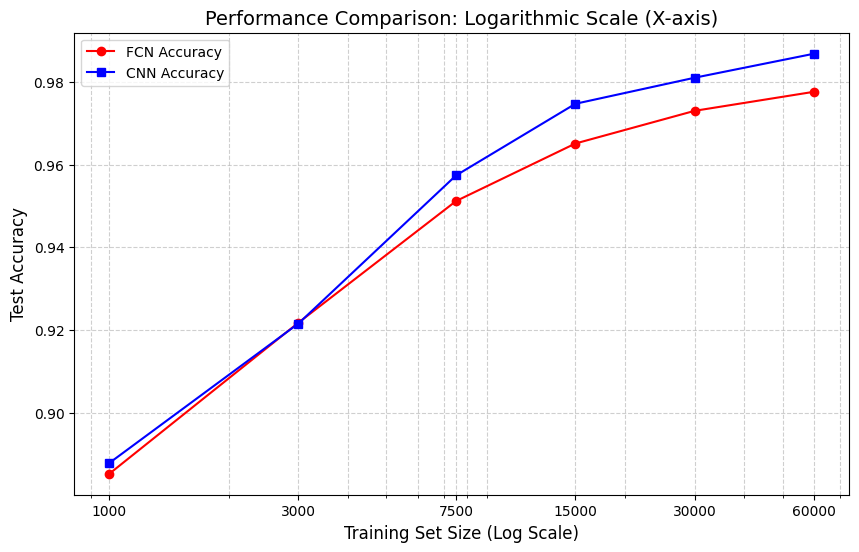


Conclusion Data Table:
   train_size  fcn_test_acc  cnn_test_acc  fcn_test_loss  cnn_test_loss
0        1000        0.8853        0.8879       0.409339       0.406857
1        3000        0.9218        0.9216       0.258018       0.261354
2        7500        0.9512        0.9574       0.155360       0.138699
3       15000        0.9651        0.9747       0.118817       0.082416
4       30000        0.9730        0.9810       0.093083       0.058144
5       60000        0.9776        0.9868       0.073862       0.041473


In [63]:
# Visualize the plot
plt.figure(figsize=(10, 6))
plt.plot(res_table['train_size'], res_table['fcn_test_acc'],
         marker='o', linestyle='-', color='red', label='FCN Accuracy')
plt.plot(res_table['train_size'], res_table['cnn_test_acc'],
         marker='s', linestyle='-', color='blue', label='CNN Accuracy')
plt.xscale('log')
plt.xticks(training_sizes, [str(s) for s in training_sizes])
plt.title('Performance Comparison: Logarithmic Scale (X-axis)', fontsize=14)
plt.xlabel('Training Set Size (Log Scale)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.legend()
plt.show()
print("\nConclusion Data Table:")
print(res_table[['train_size', 'fcn_test_acc', 'cnn_test_acc', 'fcn_test_loss', 'cnn_test_loss']])

**Conclusion**

Based on the experimental results, I believe the FCN model reached a plateau first: although both models continued to improve after 5 epochs of training, the FCN demonstrated significantly lower data efficiency. Its final accuracy at 60,000 samples (97.76%) was approximately equivalent to the level achieved by the CNN with only 15,000 samples (97.47%).
